# 📊 Model Comparison Results on CIFAR-10

## Performance Overview

| Model | Params (M) | FLOPs (MFLOPs) | Training Time (min) | Final Val Accuracy |
|------|------------|----------------|---------------------|--------------------|
| Standard CNN | 0.61 | 14.26 | 58.8 | **83.34%** |
| Residual Network | 1.25 | 167.25 | 65.8 | **90.80%** |
| ResNet (Bottleneck) | 0.24 | 124.36 | 67.7 | **89.00%** |
| Vision Transformer | 6.03 | 782.64 | 72.6 | **85.94%** |

In [1]:
from models.cnn import ConvNet
from models.residual_net import ResidualNet, ResNetBottleneck
from models.transformer import VisionTransformer
import pandas as pd
import torch
import torch.nn as nn
from typing import Dict

models : Dict[str, nn.Module] = {
    "cnn": ConvNet(c_in=3, height=32, width=32, n_classes=10),
    "resnet": ResidualNet(),
    "resnet_bn" : ResNetBottleneck(),
    "vit": VisionTransformer(patch_size=4, d_emb=288, n_blocks=6, n_heads=4, n_classes=10, p_dropout=0.2)
}

model_names : Dict[str, nn.Module] = {
    "cnn": "Standard Convolutional Network",
    "resnet": "Residual Network",
    "resnet_bn" : "Residual Network (with bottleneck blocks)",
    "vit": "Vision Transformer"
}

model_metrics = {model_id: pd.read_csv(f'training_metrics/{model_id}.csv') for model_id in models.keys()}
tr_times = {model_id: model_metrics[model_id]['total_time'].iloc[0] for model_id in model_metrics.keys()}

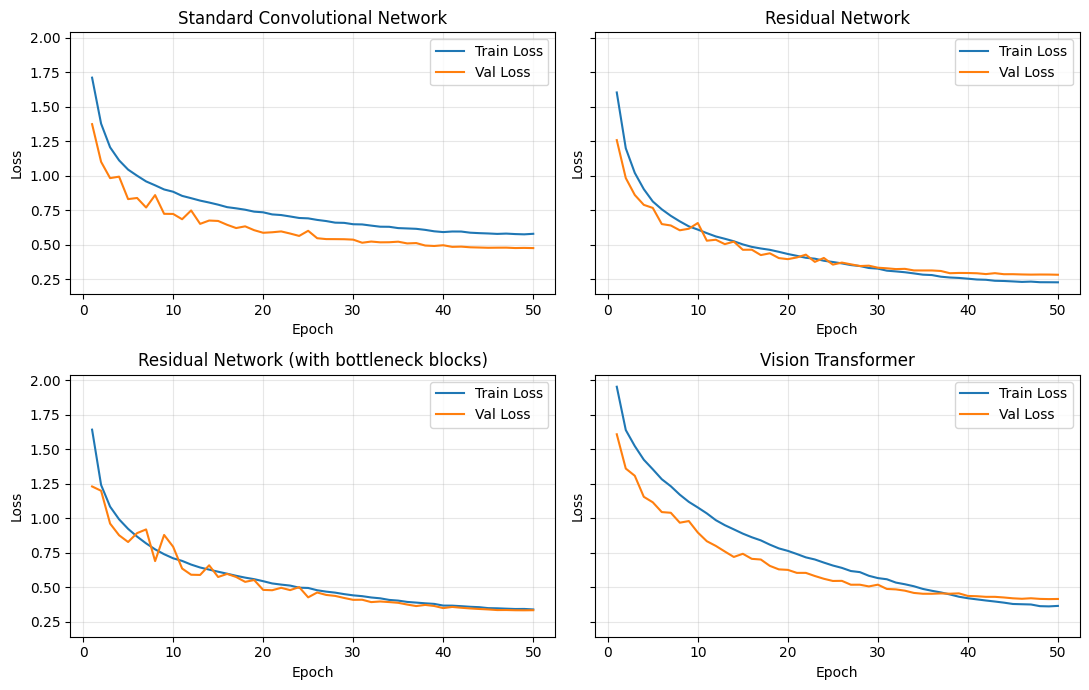

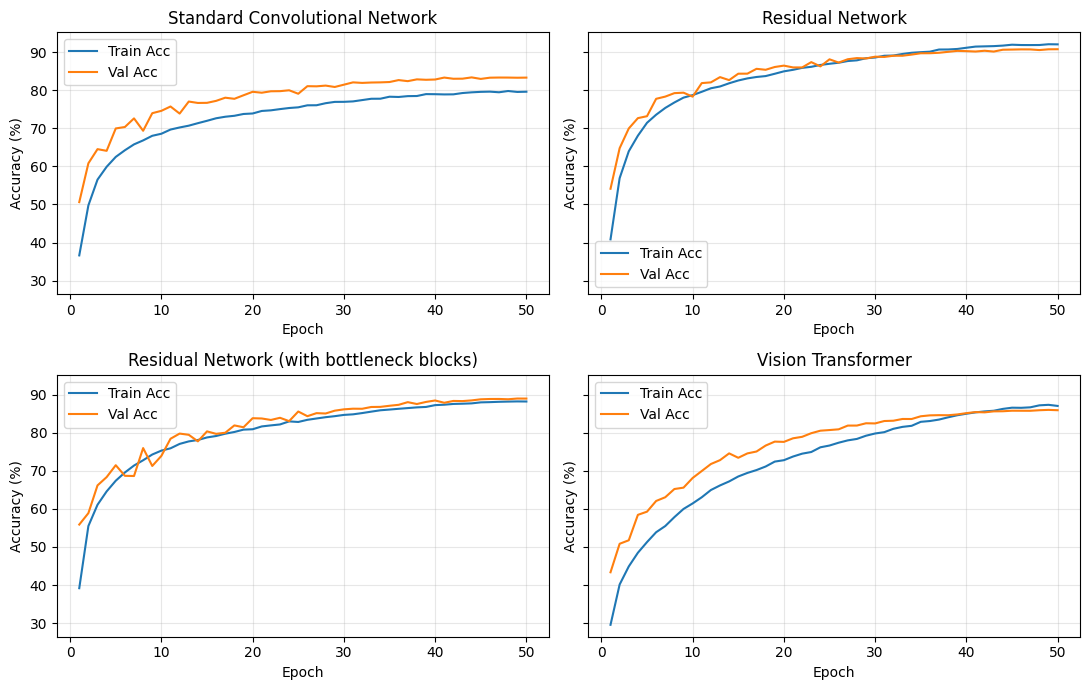

In [2]:
import matplotlib.pyplot as plt

def plot_model_metrics(model_metrics: dict):
    # --- LOSS FIGURE ---
    fig_loss, axes_loss = plt.subplots(2, 2, sharey=True, figsize=(11, 7))
    axes_loss = axes_loss.flatten()

    # --- ACCURACY FIGURE ---
    fig_acc, axes_acc = plt.subplots(2, 2, sharey=True, figsize=(11, 7))
    axes_acc = axes_acc.flatten()

    for i, (model_id, df) in enumerate(model_metrics.items()):
        epochs = range(1, len(df) + 1)

        # ---- LOSS ----
        ax_l = axes_loss[i]
        ax_l.plot(epochs, df["train_loss"], label="Train Loss")
        ax_l.plot(epochs, df["val_loss"], label="Val Loss")
        ax_l.set_title(model_names[model_id])
        ax_l.set_xlabel("Epoch")
        ax_l.set_ylabel("Loss")
        ax_l.grid(True, alpha=0.3)
        ax_l.legend()

        # ---- ACCURACY ----
        ax_a = axes_acc[i]
        ax_a.plot(epochs, df["train_acc"], label="Train Acc")
        ax_a.plot(epochs, df["val_acc"], label="Val Acc")
        ax_a.set_title(model_names[model_id])
        ax_a.set_xlabel("Epoch")
        ax_a.set_ylabel("Accuracy (%)")
        ax_a.grid(True, alpha=0.3)
        ax_a.legend()

    fig_loss.tight_layout()
    fig_acc.tight_layout()

    plt.show()

plot_model_metrics(model_metrics)

In [7]:
from data import get_loaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
accs = {}

# Final validation loop
for model_id, model in models.items():
    model.load_state_dict(torch.load(f"trained_models/{model_id}.pth", map_location=device))
    model.to(device)
    model.eval()
    
    print("Successfully loaded trained weights for " + model_id)
    
    _, val_loader = get_loaders()

    n_correct = 0
    n_total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            pred = model(imgs)
            _, predicted = torch.max(pred, dim=1)

            n_total += len(labels)
            n_correct += (predicted == labels).sum()

    accs[model_id] = n_correct/n_total
    print(f"Final validation accuracy: {accs[model_id]:.2%}")
    print("-"*40)

    

Successfully loaded trained weights for cnn
Final validation accuracy: 83.34%
----------------------------------------
Successfully loaded trained weights for resnet
Final validation accuracy: 90.80%
----------------------------------------
Successfully loaded trained weights for resnet_bn
Final validation accuracy: 89.00%
----------------------------------------
Successfully loaded trained weights for vit
Final validation accuracy: 85.94%
----------------------------------------


In [6]:
from ptflops import get_model_complexity_info

for model_id, model in models.items():
    macs, params = get_model_complexity_info(
        model, (3, 32, 32),
        as_strings=False,
        print_per_layer_stat=False
    )
    print(model_names[model_id])
    print(f"Params: {params/1e6:.2f}M")
    print(f"FLOPs: {2*macs/1e6:.2f} MFLOPs")
    print(f"Total training time: {tr_times[model_id]/60:.1f} min")
    print(f"Final validation accuracy: {accs[model_id]:.2%}")
    print("-"*40)

Standard Convolutional Network
Params: 0.61M
FLOPs: 14.26 MFLOPs
Total training time: 58.8 min
Final validation accuracy: 83.34%
----------------------------------------
Residual Network
Params: 1.25M
FLOPs: 167.25 MFLOPs
Total training time: 65.8 min
Final validation accuracy: 90.80%
----------------------------------------
Residual Network (with bottleneck blocks)
Params: 0.24M
FLOPs: 124.36 MFLOPs
Total training time: 67.7 min
Final validation accuracy: 89.00%
----------------------------------------
Vision Transformer
Params: 6.03M
FLOPs: 782.64 MFLOPs
Total training time: 72.6 min
Final validation accuracy: 85.94%
----------------------------------------
